# AON snRNA-seq Clustering and Annotation

Clustering and annotation for mouse Anterior Olfactory Nucleus (AON) snRNA-seq, starting
from the post-DecontX checkpoint produced by `01_preprocessing.ipynb`.

Pipeline: Scrublet doublet removal (scored on raw counts) -> normalization -> feature
selection -> PCA -> Leiden clustering with a quantitative resolution choice -> marker-based
annotation using fraction-of-nuclei-expressing.

**Input**: `AON_post_decontx.h5ad`  |  **Output**: `AON_preprocessed.h5ad`

In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import yaml
from sklearn.metrics import silhouette_score

sc.settings.set_figure_params(dpi=80, facecolor="white")

ROOT = Path("..")
with open(ROOT / "config/config.yaml") as fh:
    cfg = yaml.safe_load(fh)
paths = cfg["paths"]

POST_DECONTX = ROOT / paths["aon_post_decontx"]
AON_PREPROCESSED = ROOT / paths["aon_preprocessed"]
CANDIDATE_GENES = ROOT / paths["candidate_genes"]

OUTPUT_DIR = ROOT / paths["results_dir"]
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR = OUTPUT_DIR / "figures_raw"
TAB_DIR = OUTPUT_DIR / "tables"
FIG_DIR.mkdir(exist_ok=True)
TAB_DIR.mkdir(exist_ok=True)

clustering_cfg = cfg["clustering"]
n_hvg = clustering_cfg["n_hvg"]
n_pcs = clustering_cfg["n_pcs"]
n_neighbors_clustering = clustering_cfg["n_neighbors"]
n_neighbors_embedding = clustering_cfg["n_neighbors_embedding"]
umap_min_dist = clustering_cfg["umap_min_dist"]
resolution_sweep = clustering_cfg["resolution_sweep"]
expected_resolution = clustering_cfg["resolution"]

In [2]:
import plotting_style as ps

ps.apply_style()

## Load checkpoint

The checkpoint holds raw counts in `layers['counts_raw']`, decontaminated counts in `.X`
and `layers['counts']`, and per-nucleus DecontX contamination estimates.

In [3]:
adata = sc.read_h5ad(POST_DECONTX)
print(f"Loaded checkpoint: {adata.n_obs} nuclei, {adata.n_vars} genes")

Loaded checkpoint: 35028 nuclei, 26136 genes


## Doublet detection

Run Scrublet on the **raw counts** rather than decontaminated counts. DecontX shrinks
expression toward cluster centroids, compressing the variance Scrublet uses to separate
doublets from singlets, so scoring on raw counts gives more realistic estimates.

Scrublet's automatic threshold is chosen as the valley between the singlet and simulated-doublet
score distributions. On this dataset those distributions overlap with no clean antimode, so the
automatic threshold lands in the far tail and flags far fewer nuclei than the expected multiplet
rate. When the automatic call is implausibly low, the cell below falls back to the cutoff implied
by the assay's expected rate (~6%), which is the standard choice when the bimodal threshold is
undetectable.

In [4]:
EXPECTED_DOUBLET_RATE = 0.06

# Score doublets on raw counts. Build a lightweight object holding only the raw counts so the
# decontaminated layers are not copied (keeps Scrublet's memory footprint down).
adata_raw = ad.AnnData(X=adata.layers["counts_raw"].copy(), var=adata.var[[]].copy())
sc.pp.scrublet(adata_raw, expected_doublet_rate=EXPECTED_DOUBLET_RATE, random_state=0)
adata.obs["doublet_score"] = adata_raw.obs["doublet_score"].to_numpy()
adata.obs["predicted_doublet"] = adata_raw.obs["predicted_doublet"].to_numpy()
adata.uns["scrublet"] = adata_raw.uns["scrublet"]
del adata_raw

scores = adata.obs["doublet_score"].to_numpy()
auto_threshold = float(adata.uns["scrublet"].get("threshold", np.inf))
n_auto = int((scores > auto_threshold).sum())
expected_n = EXPECTED_DOUBLET_RATE * scores.size

# Fall back to the expected-rate quantile when the automatic threshold is implausibly low.
if n_auto < 0.5 * expected_n:
    threshold = float(np.quantile(scores, 1 - EXPECTED_DOUBLET_RATE))
    adata.obs["predicted_doublet"] = scores > threshold
    print(f"Scrublet automatic threshold ({auto_threshold:.3f}) flags only {n_auto} nuclei, far "
          f"below the ~{expected_n:.0f} expected at a {EXPECTED_DOUBLET_RATE:.0%} rate; the score "
          f"distributions overlap with no clean cutoff. Using expected-rate fallback threshold "
          f"{threshold:.3f}.")
else:
    threshold = auto_threshold
    print(f"Scrublet automatic threshold: {threshold:.3f}.")

print(f"Predicted doublets: {int(adata.obs['predicted_doublet'].sum())} "
      f"({adata.obs['predicted_doublet'].mean():.1%})")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Scrublet automatic threshold (0.628) flags only 1 nuclei, far below the ~2102 expected at a 6% rate; the score distributions overlap with no clean cutoff. Using expected-rate fallback threshold 0.207.
Predicted doublets: 2076 (5.9%)


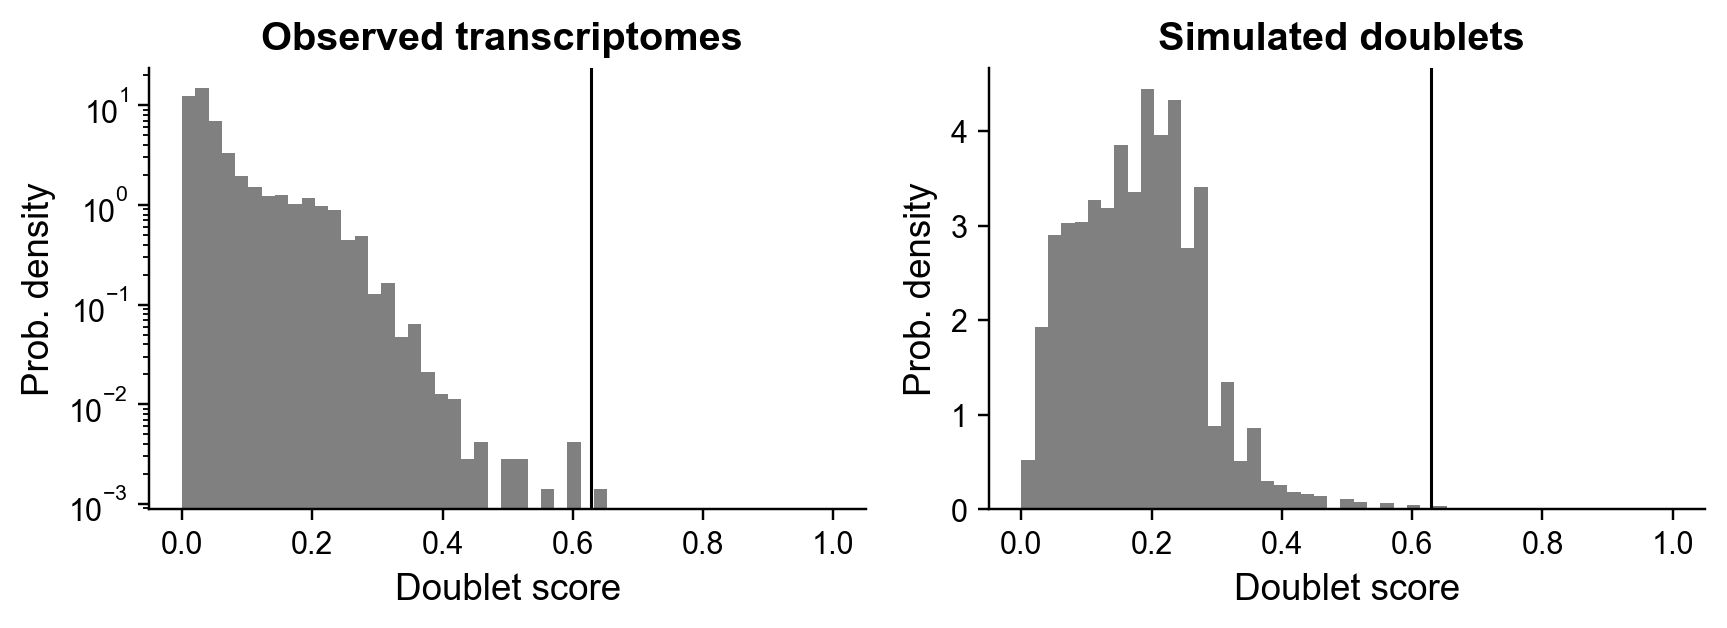

In [5]:
sc.pl.scrublet_score_distribution(adata)

### Remove doublets

Drop Scrublet-flagged doublets before clustering so multiplets do not form spurious
intermediate clusters that co-express markers of two cell types. The fraction removed is
checked against the expected rate as a calibration guard.

In [6]:
n_before = adata.n_obs
keep = ~adata.obs["predicted_doublet"].to_numpy()
frac_flagged = 1 - keep.mean()
print(f"Flagged doublets: {int((~keep).sum())} ({frac_flagged:.1%})")
if frac_flagged > 0.15:
    print("WARNING: doublet fraction far exceeds the expected ~6%. Scrublet's automatic "
          "threshold may be miscalibrated here, inspect the score distribution above.")
adata = adata[keep].copy()
print(f"Nuclei retained: {n_before} -> {adata.n_obs}")

Flagged doublets: 2076 (5.9%)


Nuclei retained: 35028 -> 32952


## Normalization

Median-library-size normalization followed by log1p, applied to the decontaminated counts.

In [7]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

## Feature selection

Select the 2,000 most highly variable genes.

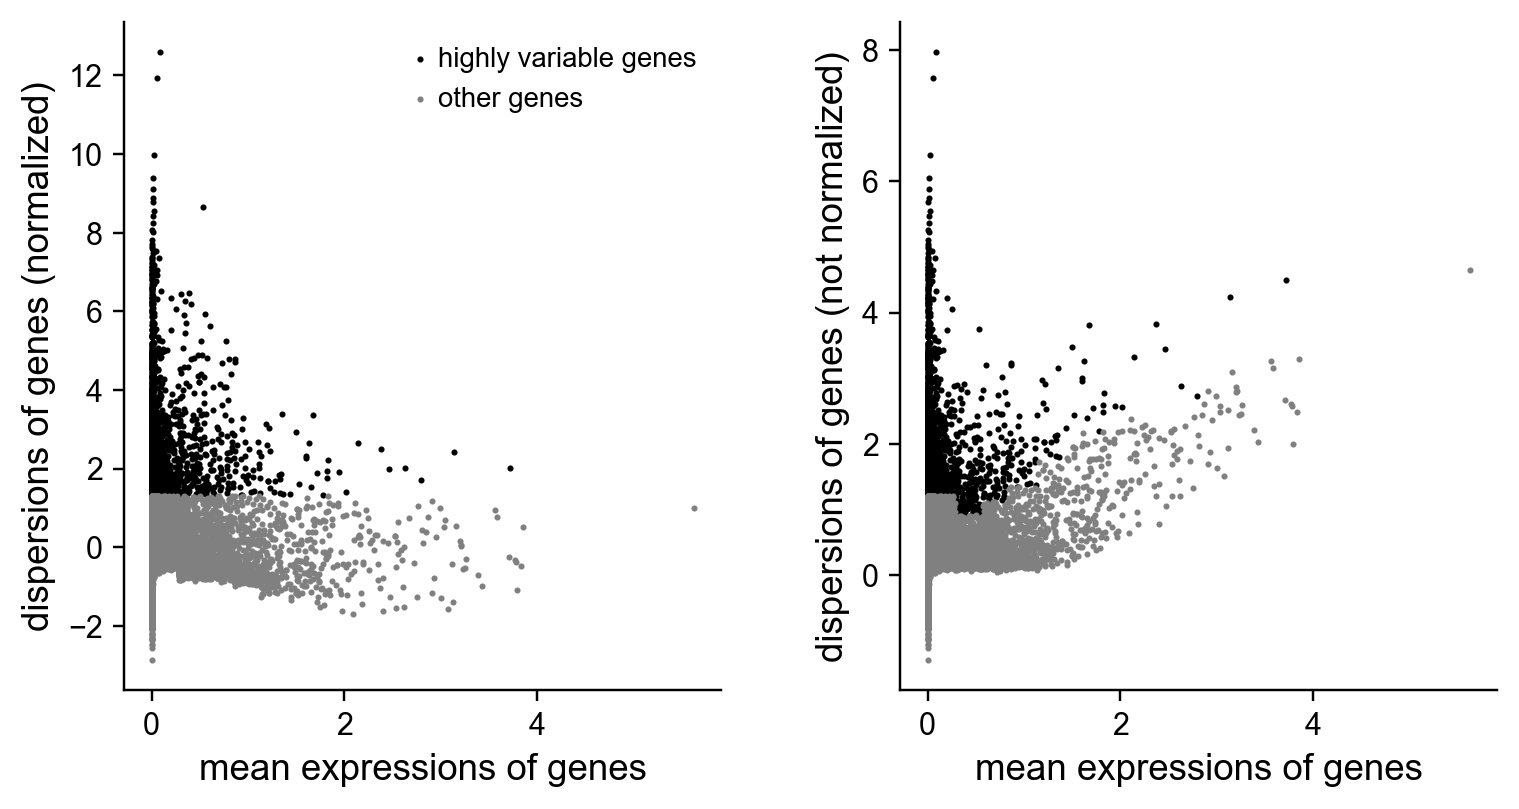

In [8]:
sc.pp.highly_variable_genes(adata, n_top_genes=n_hvg)
sc.pl.highly_variable_genes(adata)

## Dimensionality reduction

PCA computed on 2000 highly variable genes.


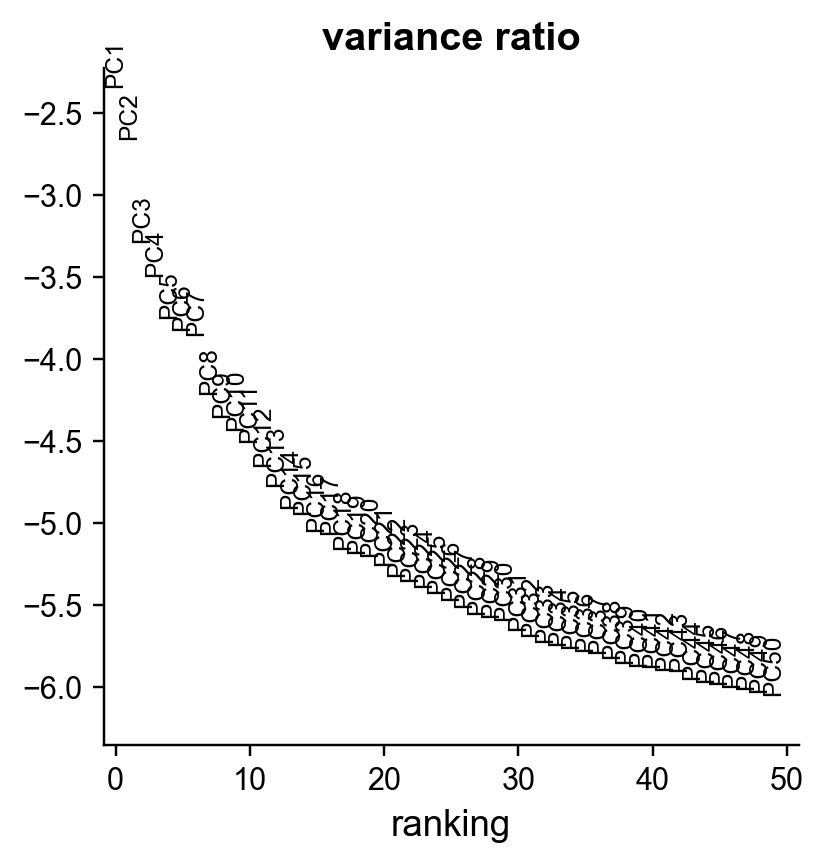

In [9]:
# Pin PCA to the HVG mask explicitly so a cleared column or default change cannot silently include all genes.
n_hvg_actual = int(adata.var["highly_variable"].sum())
assert n_hvg_actual == n_hvg, f"expected {n_hvg} highly variable genes feeding PCA, got {n_hvg_actual}"
sc.tl.pca(adata, n_comps=50, mask_var="highly_variable", random_state=42)
print(f"PCA computed on {n_hvg_actual} highly variable genes.")
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

## Neighbor graph and UMAP

Two KNN graphs are built in 30-PC space. The clustering graph uses `n_neighbors=15`
(appropriate for a dataset of this size and below the value that risks merging rare subtypes)
and is the graph Leiden partitions. A second, higher-connectivity graph (`n_neighbors=50`,
`min_dist=0.8`) is built for the UMAP layout only. Raising both recovers more global structure,
so inter-cluster gaps read less like hard islands. The clustering is unchanged because Leiden
keeps using the 15-neighbour graph. All three values are read from `config.yaml`.

In [10]:
sc.pp.neighbors(adata, n_pcs=n_pcs, n_neighbors=n_neighbors_clustering, random_state=42)
sc.pp.neighbors(adata, n_pcs=n_pcs, n_neighbors=n_neighbors_embedding, random_state=42,
                key_added="umap_graph")
sc.tl.umap(adata, neighbors_key="umap_graph", min_dist=umap_min_dist, random_state=42)

## Clustering with a quantitative resolution choice

Rather than fixing a resolution by eye, scan a range, score each clustering by silhouette in
PCA space (subsampled for tractability), and require every cluster to hold at least 20 nuclei
so the choice is not driven by tiny unstable clusters. The selected labeling is stored as
`leiden`.

Silhouette favours coarser partitions, so it picks a stable resolution rather than the true
subtype count. Finer structure is checked below via per-cluster markers.

In [11]:
resolutions = resolution_sweep
rng = np.random.default_rng(42)
sample_idx = rng.choice(adata.n_obs, size=min(5000, adata.n_obs), replace=False)
pca = adata.obsm["X_pca"][:, :n_pcs]

selection = []
for res in resolutions:
    key = f"leiden_res_{res:.1f}"
    sc.tl.leiden(adata, key_added=key, resolution=res, flavor="igraph",
                 n_iterations=2, random_state=42)
    labels = adata.obs[key].astype(int).to_numpy()
    n_clusters = adata.obs[key].nunique()
    min_size = int(adata.obs[key].value_counts().min())
    sil = silhouette_score(pca[sample_idx], labels[sample_idx]) if n_clusters > 1 else float("nan")
    selection.append({"resolution": res, "n_clusters": n_clusters,
                      "min_cluster_size": min_size, "silhouette": round(sil, 4)})

selection = pd.DataFrame(selection)
print(selection.to_string(index=False))

eligible = selection[selection["min_cluster_size"] >= 20]
best = (eligible if len(eligible) else selection).sort_values("silhouette").iloc[-1]
chosen_res = best["resolution"]
adata.obs["leiden"] = adata.obs[f"leiden_res_{chosen_res:.1f}"]
print(f"\nSelected resolution {chosen_res}: {int(best['n_clusters'])} clusters, "
      f"silhouette {best['silhouette']}.")

# The resolution recorded in config is the expected outcome of this sweep. Fail loudly if a
# dependency change ever shifts the silhouette-selected value, rather than drifting silently.
assert abs(chosen_res - expected_resolution) < 1e-9, (
    f"silhouette selected resolution {chosen_res}, config records {expected_resolution}; "
    f"reconcile config/config.yaml or investigate the drift"
)

 resolution  n_clusters  min_cluster_size  silhouette
        0.1          22               159      0.2970
        0.2          22                38      0.2927
        0.3          23                38      0.2969
        0.5          26                24      0.2764
        0.8          29                32      0.2381
        1.0          36                23      0.2188

Selected resolution 0.1: 22 clusters, silhouette 0.297.


In [ ]:
from matplotlib.lines import Line2D

n_leiden = adata.obs["leiden"].nunique()
palette = ps.cluster_palette(n_leiden)

fig, ax = plt.subplots(figsize=(9, 6.5))
sc.pl.umap(adata, color="leiden", palette=palette, ax=ax, show=False, size=6,
           legend_loc="on data", legend_fontsize=7, legend_fontoutline=2, frameon=True,
           title=f"Leiden clusters (resolution {chosen_res}, silhouette-selected)")
ax.set_aspect("equal")
cats = list(adata.obs["leiden"].cat.categories)
colors = list(adata.uns["leiden_colors"])
handles = [Line2D([0], [0], marker="o", ls="", color=colors[i], label=cats[i], markersize=6)
           for i in range(len(cats))]
ax.legend(handles=handles, title="cluster", loc="center left", bbox_to_anchor=(1.02, 0.5),
          ncol=2, frameon=False, fontsize=8, handletextpad=0.2, columnspacing=0.8)
ps.save_fig(fig, FIG_DIR / "umap_leiden_clusters", close=False)
plt.show()


### Post-clustering quality check

With doublets already removed, this step verifies that no residual cluster is technical in
origin. A cluster driven by technical signal would warrant a second look before annotation.

In [ ]:
sc.pl.umap(adata, color=["leiden", "doublet_score", "decontX_contamination"],
           wspace=0.4, ncols=3, size=3)
sc.pl.umap(adata, color=["log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
           wspace=0.4, ncols=3, size=3)

In [14]:
cluster_qc = adata.obs.groupby("leiden", observed=True).agg(
    n_nuclei=("doublet_score", "size"),
    mean_doublet_score=("doublet_score", "mean"),
    mean_contamination=("decontX_contamination", "mean"),
    mean_n_genes=("n_genes_by_counts", "mean"),
)
cluster_qc["mean_contamination"] = (cluster_qc["mean_contamination"] * 100).round(1)
cluster_qc["mean_doublet_score"] = cluster_qc["mean_doublet_score"].round(3)
cluster_qc["mean_n_genes"] = cluster_qc["mean_n_genes"].round(0)
print(cluster_qc.sort_values("mean_doublet_score", ascending=False).to_string())

        n_nuclei  mean_doublet_score  mean_contamination  mean_n_genes
leiden                                                                
8            331               0.123                21.3        3660.0
4           3877               0.089                44.8        3080.0
9            406               0.067                31.1        3141.0
11          1122               0.064                29.1        3432.0
15           416               0.064                28.1        3152.0
18          1244               0.058                23.4        3557.0
17           175               0.055                12.9        3741.0
7           3501               0.052                28.9        3155.0
1           2197               0.049                23.3        2662.0
6           2604               0.048                20.8        3557.0
16          1259               0.047                24.3        3747.0
14          1444               0.046                21.5        3751.0
19    

## Marker gene panels

Canonical markers for the neuronal and glial populations expected in the AON, shown across
clusters to guide annotation.

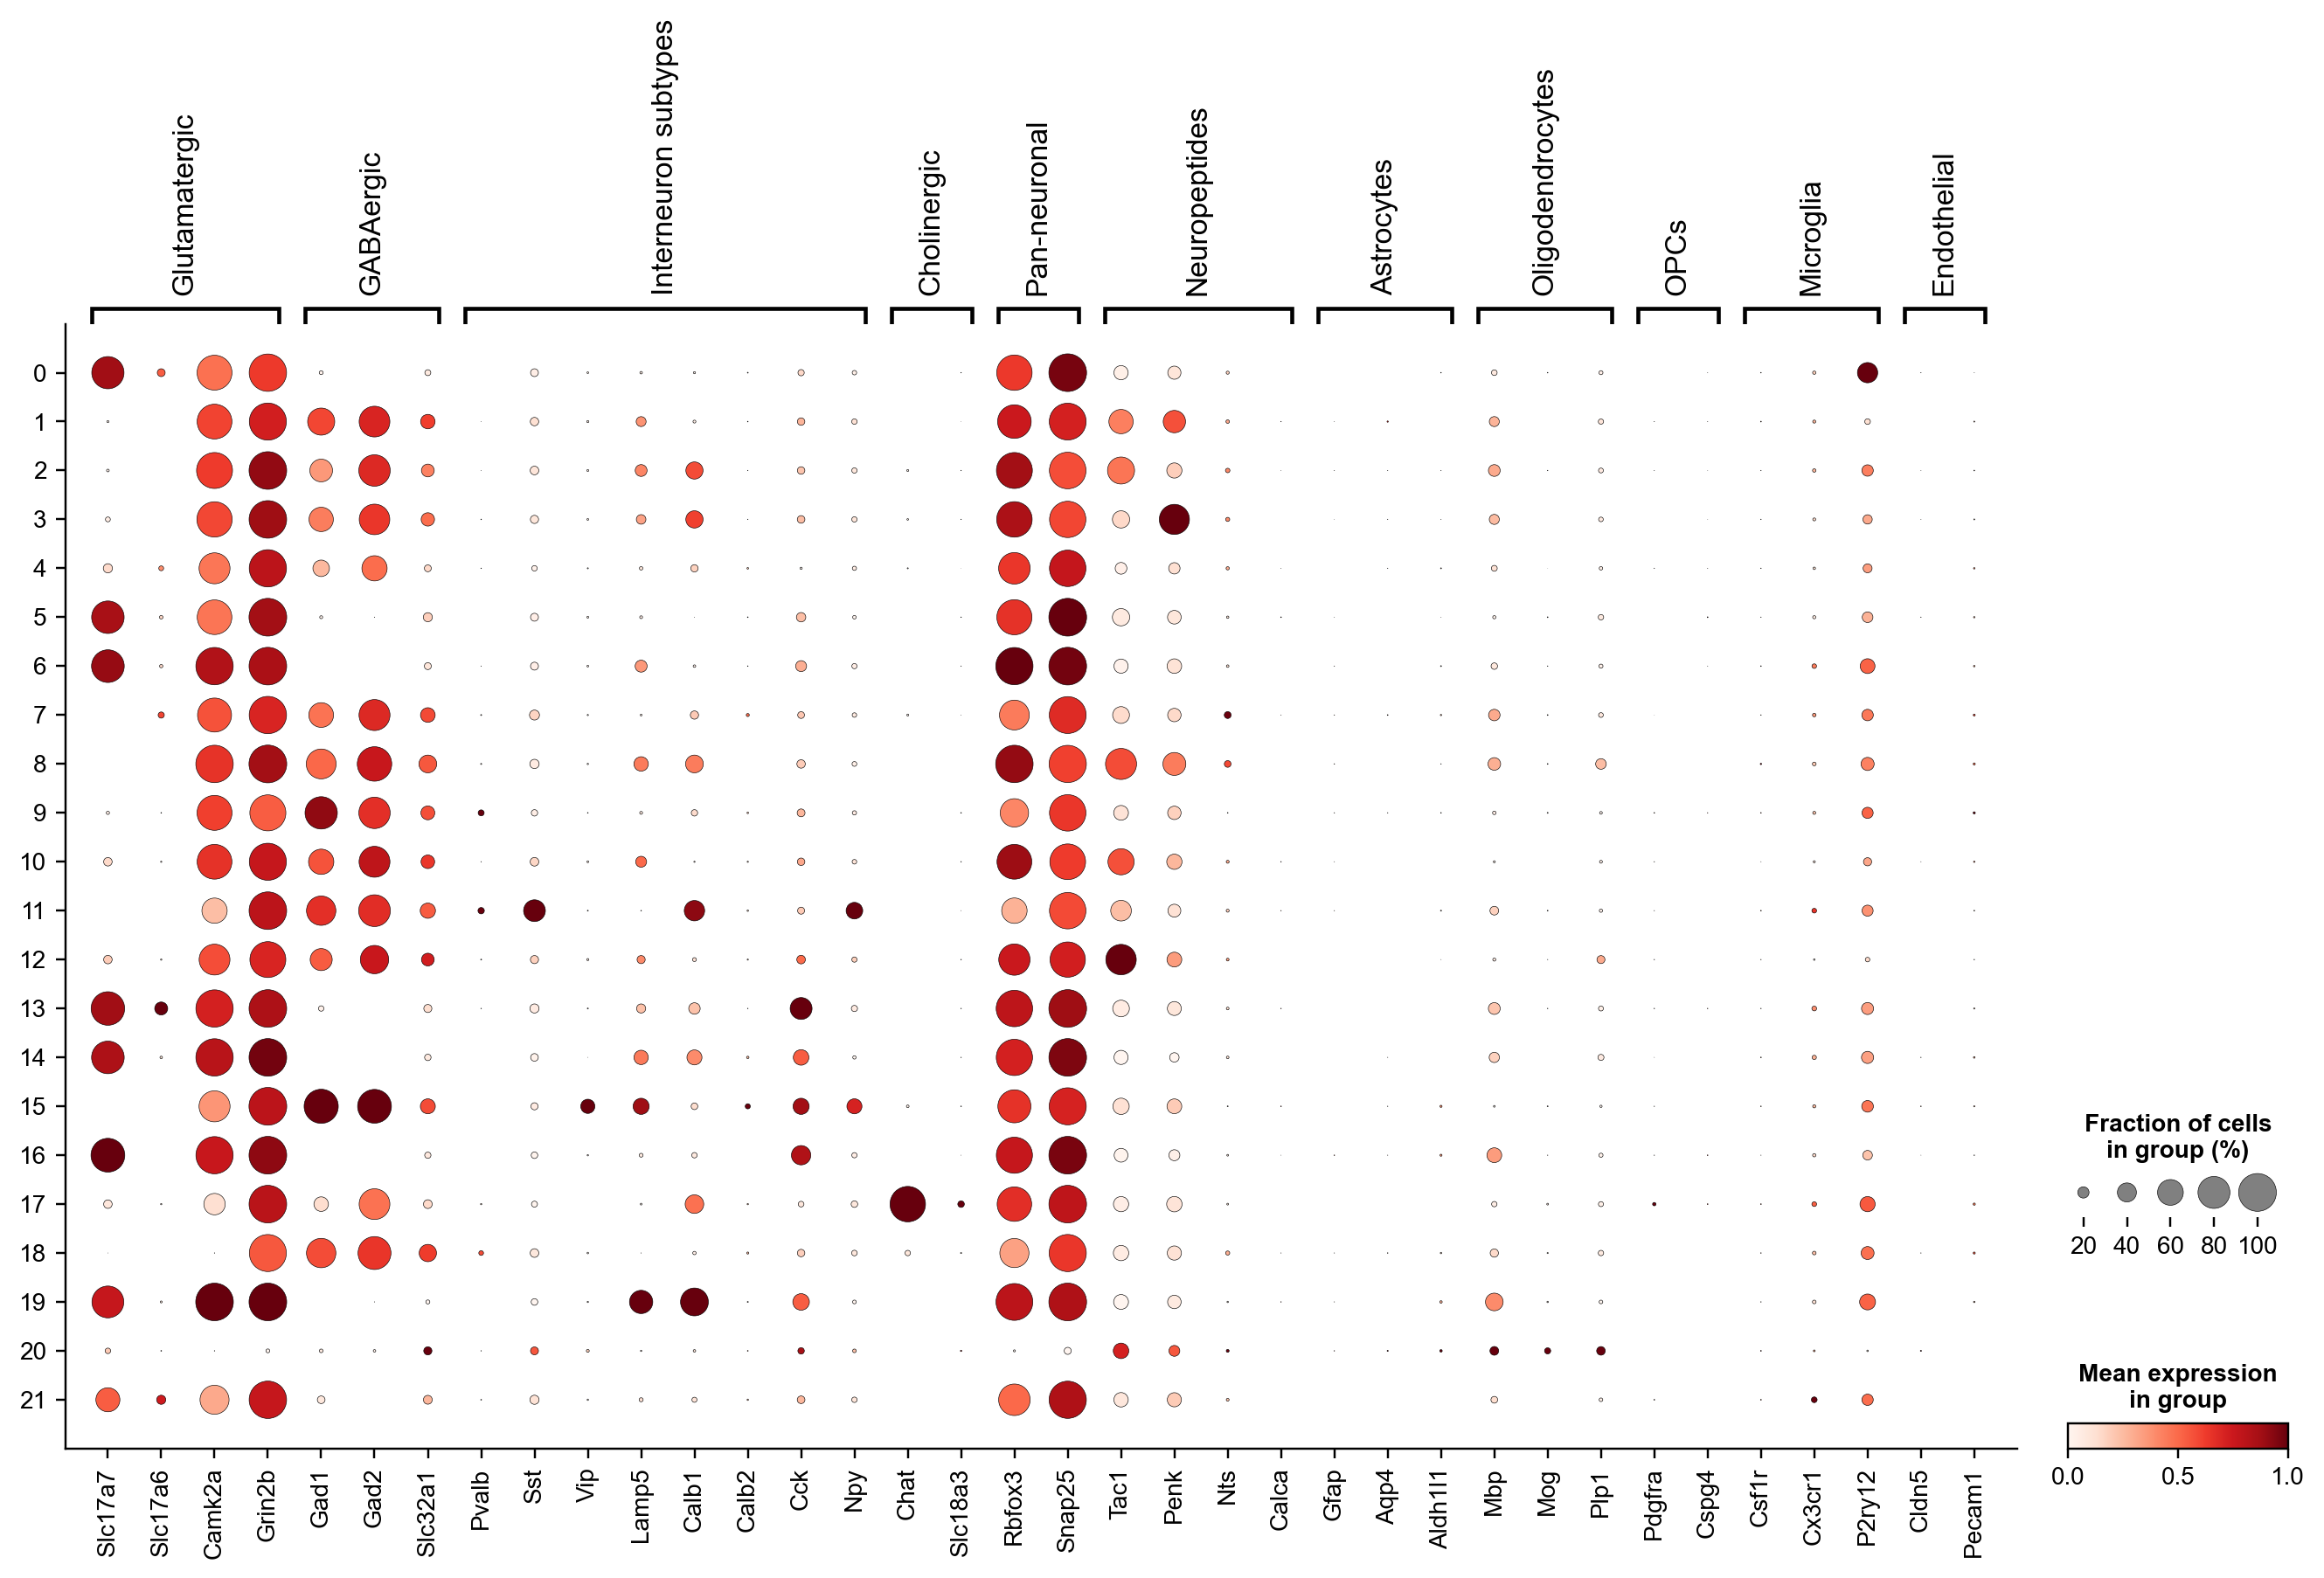

In [15]:
aon_markers = {
    "Glutamatergic": ["Slc17a7", "Slc17a6", "Camk2a", "Grin2b"],
    "GABAergic": ["Gad1", "Gad2", "Slc32a1"],
    "Interneuron subtypes": ["Pvalb", "Sst", "Vip", "Lamp5", "Calb1", "Calb2", "Cck", "Npy"],
    "Cholinergic": ["Chat", "Slc18a3"],
    "Pan-neuronal": ["Rbfox3", "Snap25"],
    "Neuropeptides": ["Tac1", "Penk", "Nts", "Calca"],
    "Astrocytes": ["Gfap", "Aqp4", "Aldh1l1"],
    "Oligodendrocytes": ["Mbp", "Mog", "Plp1"],
    "OPCs": ["Pdgfra", "Cspg4"],
    "Microglia": ["Csf1r", "Cx3cr1", "P2ry12"],
    "Endothelial": ["Cldn5", "Pecam1"],
}
sc.pl.dotplot(adata, aon_markers, groupby="leiden", standard_scale="var")

## Cell-type annotation by fraction expressing

Annotate each cluster by the fraction of its nuclei expressing a marker panel, rather than by
a mean-expression ratio that a few high-expressing nuclei can dominate. Each cluster is called
for its dominant lineage (the panel with the highest fraction expressing, which must clear
25%). A cluster is flagged mixed only when a second lineage is genuinely co-dominant (within
15 points of the top and also above 25%). The margin prevents low-level ambient glial signal in
neuron-enriched clusters from producing spurious mixed calls.

In [16]:
marker_panels = {
    "Excitatory": ["Slc17a7", "Slc17a6"],
    "Inhibitory": ["Gad1", "Gad2", "Slc32a1"],
    "Astrocyte": ["Gfap", "Aqp4", "Aldh1l1"],
    "Oligodendrocyte": ["Mbp", "Mog", "Plp1"],
    "OPC": ["Pdgfra", "Cspg4"],
    "Microglia": ["Csf1r", "Cx3cr1", "P2ry12"],
    "Endothelial": ["Cldn5", "Pecam1"],
}
EXPR_FRACTION = cfg["annotation"]["expressing_threshold"]
counts = adata.layers["counts"]


def fraction_expressing(genes):
    """Fraction of nuclei per cluster expressing any gene in the panel (count > 0)."""
    present = [g for g in genes if g in adata.var_names]
    if not present:
        return pd.Series(0.0, index=adata.obs["leiden"].cat.categories)
    idx = [adata.var_names.get_loc(g) for g in present]
    any_expr = np.asarray((counts[:, idx] > 0).sum(axis=1)).ravel() > 0
    return pd.Series(any_expr, index=adata.obs.index).groupby(
        adata.obs["leiden"], observed=True).mean()


frac = pd.DataFrame({cls: fraction_expressing(g) for cls, g in marker_panels.items()})
MARGIN = cfg["annotation"]["mixed_margin"]


def call_cluster(row):
    """Dominant lineage by fraction expressing, flagging only genuine co-dominance.

    Returns the top lineage if it clears EXPR_FRACTION, "Unassigned" otherwise. A second
    lineage is reported as co-dominant only when it also clears the threshold and sits within
    MARGIN of the top, so low-level ambient signal does not produce spurious mixed calls.
    """
    ordered = row.sort_values(ascending=False)
    if ordered.iloc[0] < EXPR_FRACTION:
        return "Unassigned"
    if ordered.iloc[1] >= EXPR_FRACTION and (ordered.iloc[0] - ordered.iloc[1]) <= MARGIN:
        return f"{ordered.index[0]} + {ordered.index[1]} (mixed)"
    return ordered.index[0]


assignment = frac.apply(call_cluster, axis=1)

frac_display = (frac * 100).round(0).astype(int)
frac_display["call"] = assignment
print("Per-cluster fraction expressing each panel (%), with call:")
print(frac_display.to_string())

adata.obs["cell_type"] = adata.obs["leiden"].map(assignment).astype("category")

Per-cluster fraction expressing each panel (%), with call:
        Excitatory  Inhibitory  Astrocyte  Oligodendrocyte  OPC  Microglia  Endothelial        call
leiden                                                                                             
0               82          13          0               13    0         46            0  Excitatory
1                2          92          1               22    0         12            1  Inhibitory
2                3          90          0               26    0         24            1  Inhibitory
3                7          90          0               22    0         18            1  Inhibitory
4               20          70          1               12    0         17            1  Inhibitory
5               82          18          0               11    1         21            1  Excitatory
6               83          11          1               14    0         33            1  Excitatory
7                9          89          2

### Robustness cross-check and population composition

The fraction-expressing call above is a binary detection metric, which in principle could be
skewed by low-level ambient signal. The cell below re-derives the excitatory/inhibitory call
from **mean log-normalized expression** and confirms the two strategies agree.

The majority-GABAergic result is real, not ambient, because glutamatergic clusters carry
essentially no Gad. It is consistent with the original analysis of this tissue. The AON abuts
GABAergic-rich olfactory tubercle, so the exact inhibitory fraction partly reflects
microdissection scope. This step establishes neurotransmitter identity, not regional
boundaries.

In [17]:
# Cross-check the neuronal calls against mean log-normalized expression.
def cluster_mean_expression(genes):
    """Mean log-normalized expression of a panel, averaged per Leiden cluster."""
    present = [g for g in genes if g in adata.var_names]
    idx = [adata.var_names.get_loc(g) for g in present]
    vals = np.asarray(adata.X[:, idx].mean(axis=1)).ravel()
    return pd.Series(vals, index=adata.obs.index).groupby(
        adata.obs["leiden"], observed=True).mean()


neuronal_panels = {k: marker_panels[k] for k in ("Excitatory", "Inhibitory")}
mean_expr = pd.DataFrame({k: cluster_mean_expression(v) for k, v in neuronal_panels.items()})
mean_call = mean_expr.idxmax(axis=1)

frac_call = assignment.str.split(" ").str[0]
neuronal = frac_call.isin(["Excitatory", "Inhibitory"])
n_agree = int((mean_call[neuronal] == frac_call[neuronal]).sum())
print(f"Neuronal clusters where mean-expression and fraction-expressing agree on lineage: "
      f"{n_agree}/{int(neuronal.sum())} ({n_agree / int(neuronal.sum()):.0%})")

adata.obs["lineage"] = (
    adata.obs["cell_type"].astype(str).str.split(" ").str[0].astype("category")
)
composition = adata.obs["lineage"].value_counts()
print("\nPopulation composition (neurotransmitter lineage):")
for lineage, n in composition.items():
    print(f"  {lineage:12s} {n:6d}  ({n / adata.n_obs:.1%})")

Neuronal clusters where mean-expression and fraction-expressing agree on lineage: 21/21 (100%)

Population composition (neurotransmitter lineage):
  Inhibitory    23851  (72.4%)
  Excitatory     8764  (26.6%)
  Unassigned      337  (1.0%)


In [ ]:
cats = list(adata.obs["cell_type"].cat.categories)
if "Unassigned" in cats:
    cats = [c for c in cats if c != "Unassigned"] + ["Unassigned"]
    adata.obs["cell_type"] = adata.obs["cell_type"].cat.reorder_categories(cats)
palette = [ps.CELLTYPE_COLORS.get(c, "#777777") for c in cats]

fig, ax = plt.subplots(figsize=(8, 6))
sc.pl.umap(adata, color="cell_type", palette=palette, legend_loc="right margin", ax=ax,
           show=False, frameon=True, size=6, title="Annotated cell types")
ax.set_aspect("equal")
ps.save_fig(fig, FIG_DIR / "umap_cell_types", close=False)
plt.show()


### Cell-type composition and marker distributions

**Marker expression:** Slc17a7/Slc17a6 concentrate in the
Excitatory call and Gad1/Gad2/Slc32a1 in the Inhibitory call, and the composition bars report the
nucleus counts behind each lineage.

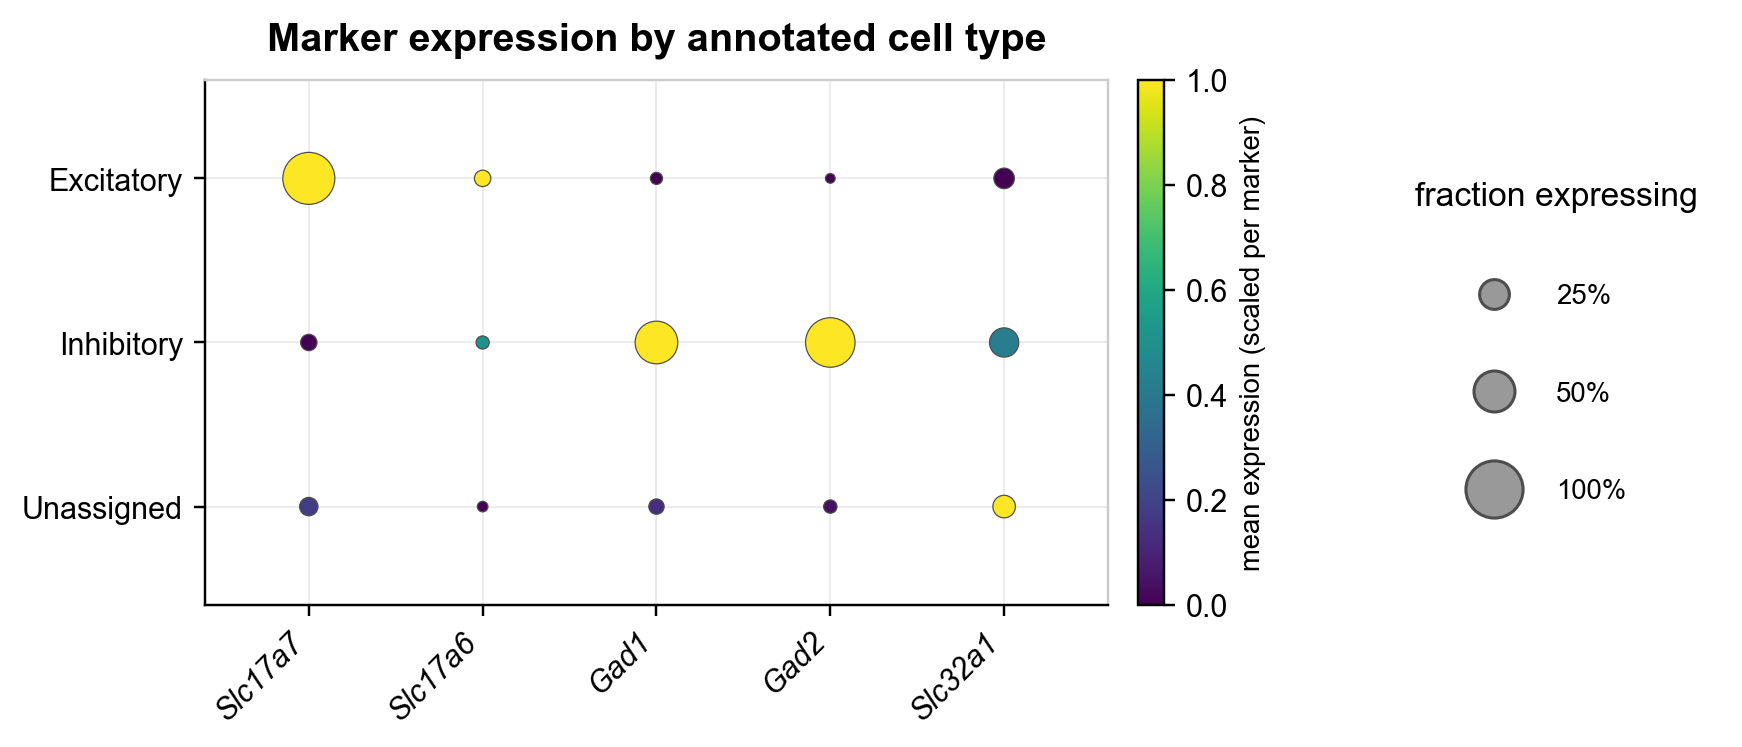

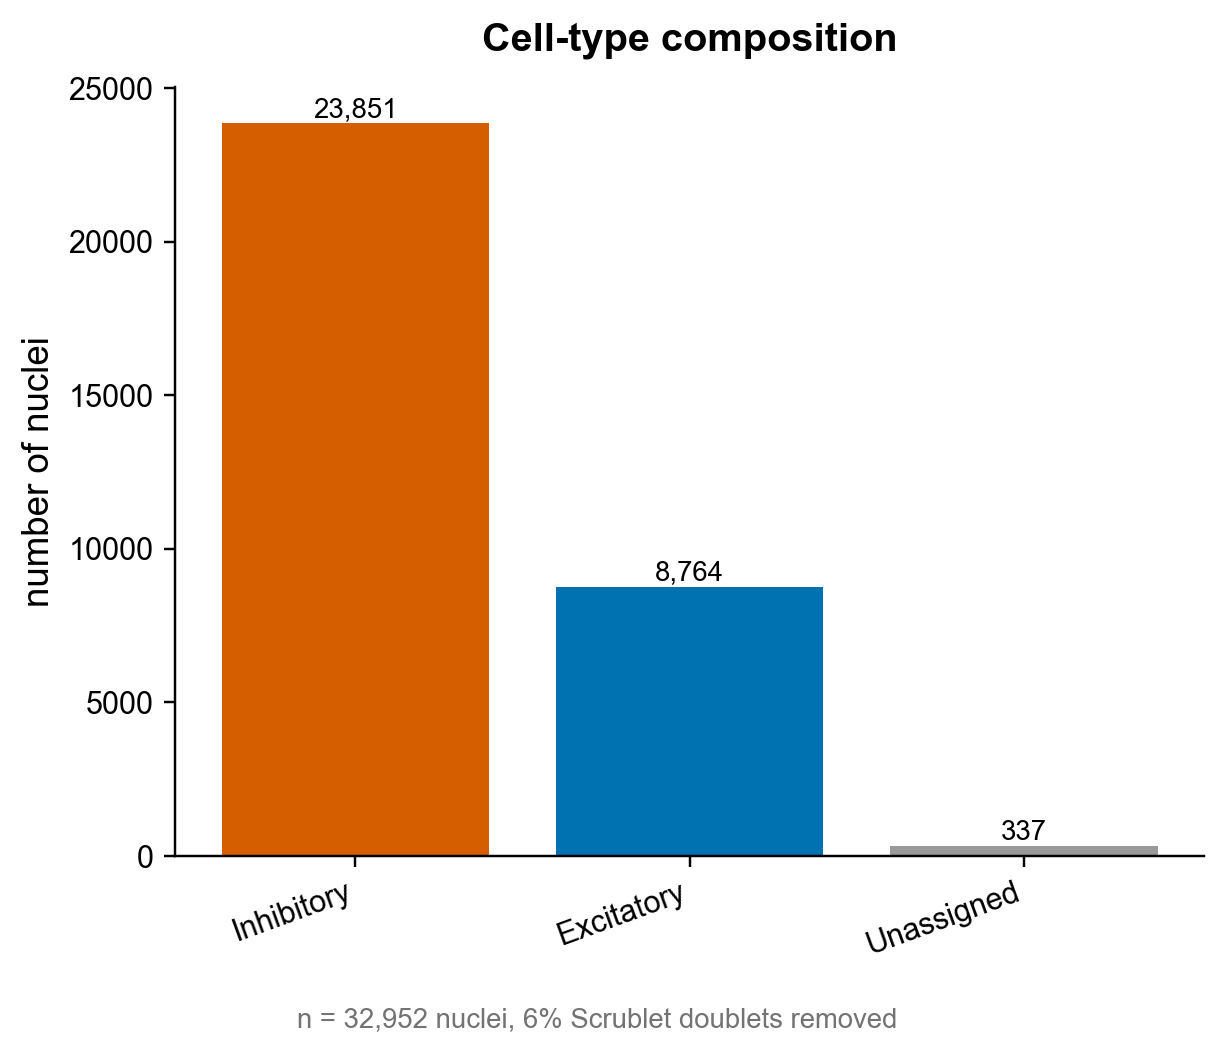

In [19]:
composition_markers = [g for g in ["Slc17a7", "Slc17a6", "Gad1", "Gad2", "Slc32a1"]
                       if g in adata.var_names]
marker_expr = sc.get.obs_df(adata, keys=composition_markers)
fig = ps.marker_dotplot(marker_expr, adata.obs["cell_type"].astype(str).values,
                        composition_markers, title="Marker expression by annotated cell type")
ps.save_fig(fig, FIG_DIR / "marker_dotplot", close=False)
plt.show()

props = adata.obs["cell_type"].value_counts()
fig, ax = plt.subplots(figsize=(6, 4.6))
ax.bar(range(len(props)), props.values,
       color=[ps.CELLTYPE_COLORS.get(c, "0.6") for c in props.index])
ax.set_xticks(range(len(props)))
ax.set_xticklabels(props.index, rotation=20, ha="right")
for i, v in enumerate(props.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("number of nuclei")
ax.set_title("Cell-type composition", pad=12)
fig.text(0.5, -0.02, f"n = {adata.n_obs:,} nuclei, 6% Scrublet doublets removed",
         ha="center", fontsize=9, color="0.45")
ps.save_fig(fig, FIG_DIR / "celltype_proportions", close=False)
plt.show()


### Cluster marker genes

One-vs-rest Wilcoxon to surface the top enriched genes per cluster. This is the appropriate
use of a cell-level test, identifying features that distinguish clusters within one dataset,
not comparing biological conditions.

scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
scanpy/tools/_rank_genes_groups.py:463: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat

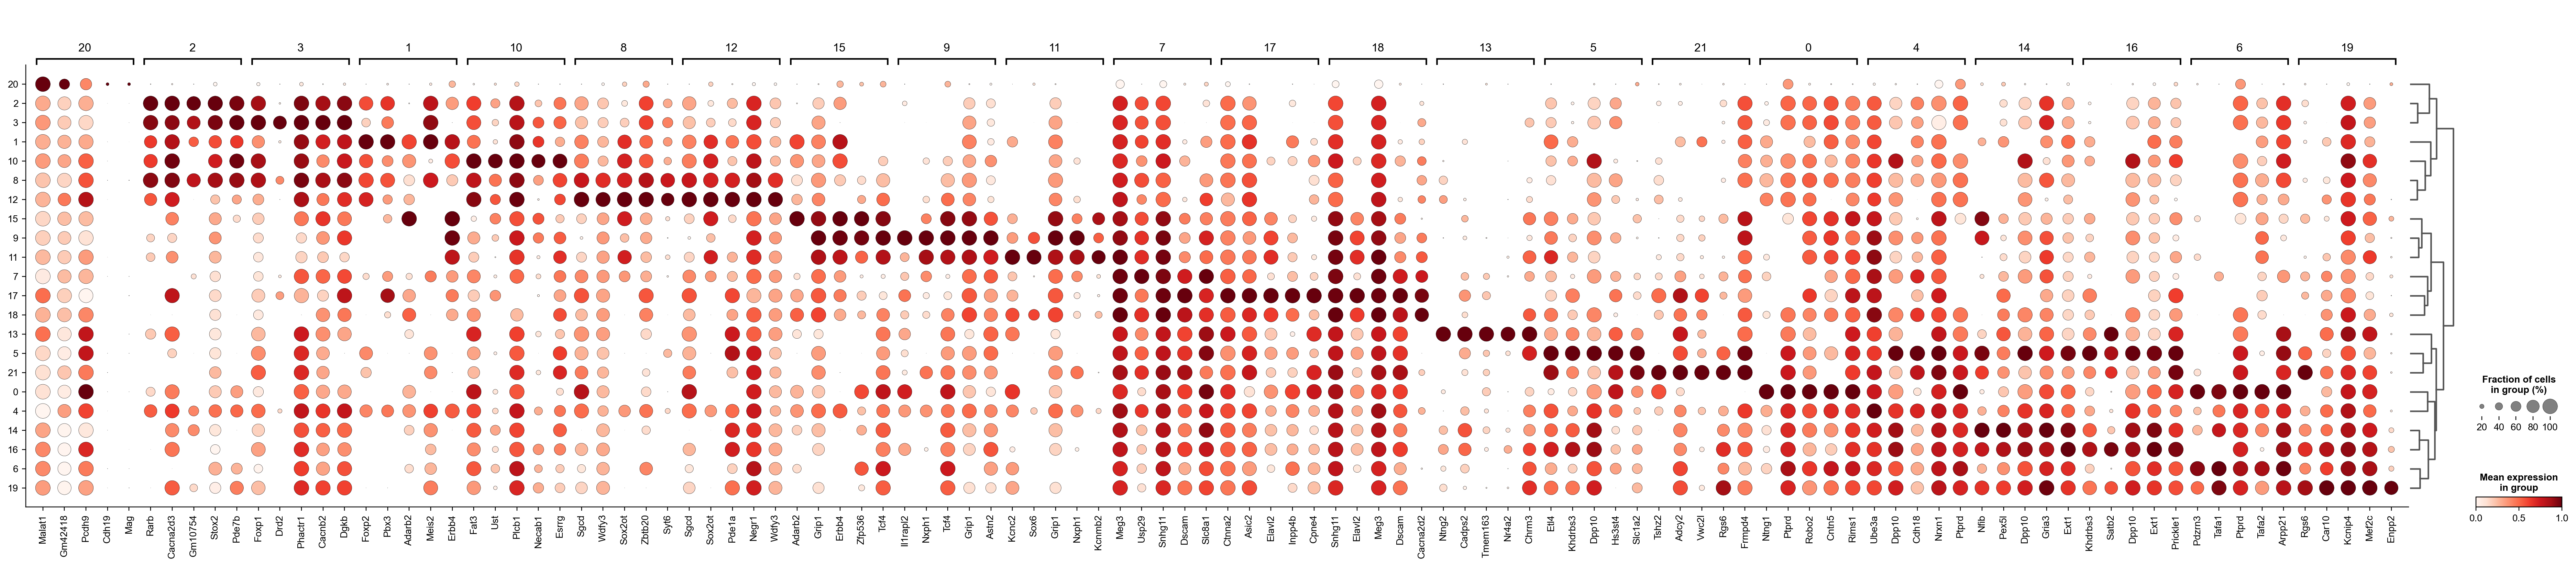

In [20]:
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(adata, groupby="leiden", standard_scale="var", n_genes=5)

### Marker-validity check

Cluster validity is judged by marker distinctness, not by how much white space separates the
islands in the UMAP (gap size is a UMAP cosmetic, not biology). For each Leiden cluster this
summarizes the one-vs-rest markers: the top genes, the strongest marker's effect size and FDR,
and how many markers clear the DE thresholds from `config.yaml`. Clusters with no marker
passing those thresholds, or whose top markers are glial rather than neuronal, are flagged for
follow-up. The table is written to `results/tables/cluster_marker_validity.csv`.

In [21]:
glial_lineages = ["Astrocyte", "Oligodendrocyte", "OPC", "Microglia", "Endothelial"]
glial_genes = {g for lineage in glial_lineages for g in marker_panels[lineage]}

de_cfg = cfg["de"]
lfc_threshold = de_cfg["log2fc"]
fdr_threshold = de_cfg["fdr"]
TOP_N = 5

cell_type_by_cluster = (
    adata.obs.drop_duplicates("leiden")
    .assign(leiden=lambda d: d["leiden"].astype(str))
    .set_index("leiden")["cell_type"].astype(str)
)

ranked = sc.get.rank_genes_groups_df(adata, group=None)
rows = []
for cluster, sub in ranked.groupby("group", observed=True):
    sub = sub.sort_values("scores", ascending=False)
    top = sub.head(TOP_N)
    n_sig = int(((sub["logfoldchanges"] >= lfc_threshold) &
                 (sub["pvals_adj"] < fdr_threshold)).sum())
    glial_hits = [g for g in top["names"] if g in glial_genes]
    flags = []
    if n_sig == 0:
        flags.append("no_distinct_markers")
    if glial_hits:
        flags.append("glial_top_markers:" + "/".join(glial_hits))
    rows.append({
        "leiden": cluster,
        "cell_type": cell_type_by_cluster.get(cluster, ""),
        "top_markers": ", ".join(top["names"]),
        "top_gene": top["names"].iloc[0],
        "top_log2fc": round(float(top["logfoldchanges"].iloc[0]), 2),
        "top_padj": float(top["pvals_adj"].iloc[0]),
        "n_markers_sig": n_sig,
        "flag": "; ".join(flags) if flags else "ok",
    })

marker_validity = pd.DataFrame(rows).sort_values("leiden", key=lambda s: s.astype(int))
marker_validity.to_csv(TAB_DIR / "cluster_marker_validity.csv", index=False)

flagged = marker_validity[marker_validity["flag"] != "ok"]
if len(flagged):
    print("Clusters flagged for follow-up (no distinct markers or glial-dominated top markers):")
    print(flagged[["leiden", "cell_type", "top_markers", "n_markers_sig", "flag"]]
          .to_string(index=False))
else:
    print(f"All {len(marker_validity)} clusters have distinct, non-glial top markers "
          f"(>= {lfc_threshold} log2FC at FDR < {fdr_threshold}).")
print(f"\nWrote {TAB_DIR / 'cluster_marker_validity.csv'}")

All 22 clusters have distinct, non-glial top markers (>= 1.0 log2FC at FDR < 0.05).

Wrote ../results/tables/cluster_marker_validity.csv


## Candidate gene exploration

Two candidate sets, kept distinct. **Set A** is the 118-gene neuromodulation/interneuron panel
(`Candidate_Genes.csv`), shown across clusters as cell-type context. **Set B** is the eight
projection candidates. The in-house glutamatergic clusters are scored for a candidate signature to
find the cluster(s) that most resemble the dorsolateral population. This is a cell-type-marker
triangulation on a single mouse, not a projection readout, and it complements the ABC-atlas contrast
in `04_differential_expression.ipynb` (the concordance notebook maps an in-house excitatory cluster
to the ABC `010 IT AON-TT-DP Glut` subclass).


Set A candidate genes found: 118/118
Candidate markers present in-house: ['Robo2', 'Abi3bp', 'Gabrg1', 'Adcyap1', 'Chrm3', 'Rprm', 'Thrb', 'Cntn5']
Top candidate-enriched excitatory cluster(s): ['6', '19', '0']
Signature (mean z of the 8 markers), top 5 clusters:
6     1.28
19    0.49
11    0.30
4     0.28
0     0.28


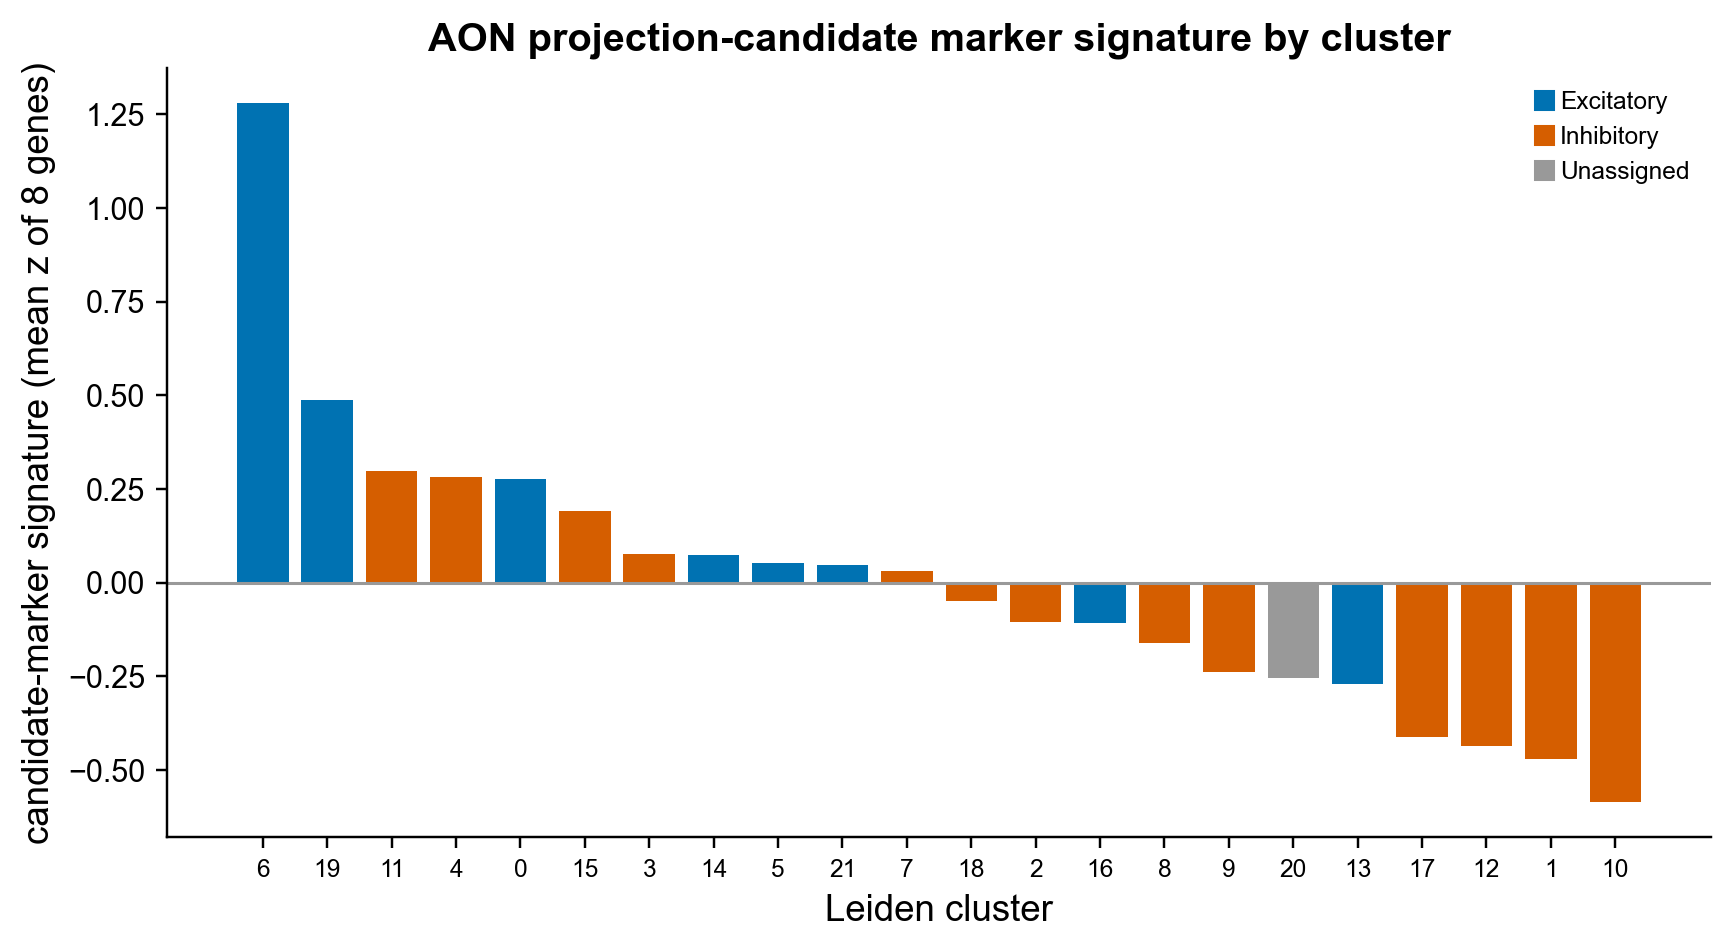

In [22]:
from matplotlib.lines import Line2D

# Set A (supporting): 118-gene neuromodulation/interneuron panel across clusters.
candidates_df = pd.read_csv(CANDIDATE_GENES)
candidate_genes = candidates_df["GeneName"].dropna().astype(str).tolist()
genes_found = [g for g in candidate_genes if g in adata.var_names]
print(f"Set A candidate genes found: {len(genes_found)}/{len(candidate_genes)}")

# Set B: score each cluster for the 8 projection candidates (mean z of log-normalized
# expression across the panel), to find the in-house glutamatergic correlate of the dorsolateral set.
table12 = ["Robo2", "Abi3bp", "Gabrg1", "Adcyap1", "Chrm3", "Rprm", "Thrb", "Cntn5"]
present12 = [g for g in table12 if g in adata.var_names]
expr12 = sc.get.obs_df(adata, keys=present12)
mean12 = expr12.groupby(adata.obs["leiden"].values, observed=True).mean()
z12 = (mean12 - mean12.mean()) / mean12.std(ddof=0)
signature = z12.mean(axis=1).sort_values(ascending=False)

ct_map = adata.obs.drop_duplicates("leiden").set_index("leiden")["cell_type"].astype(str)
exc_clusters = set(adata.obs.loc[adata.obs["cell_type"] == "Excitatory", "leiden"].astype(str))
top_exc = [c for c in signature.index.astype(str) if c in exc_clusters][:3]
print(f"Candidate markers present in-house: {present12}")
print(f"Top candidate-enriched excitatory cluster(s): {top_exc}")
print("Signature (mean z of the 8 markers), top 5 clusters:")
print(signature.head(5).round(2).to_string())

order = signature.index.tolist()
colors = [ps.CELLTYPE_COLORS.get(ct_map.get(c, ""), "0.6") for c in order]
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.bar(range(len(order)), signature.values, color=colors, zorder=2)
ax.axhline(0, color="0.6", lw=1)
ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, fontsize=8)
ax.set_xlabel("Leiden cluster")
ax.set_ylabel("candidate-marker signature (mean z of 8 genes)")
ax.set_title("AON projection-candidate marker signature by cluster")
handles = [Line2D([0], [0], marker="s", ls="", color=ps.CELLTYPE_COLORS[k], label=k)
           for k in ["Excitatory", "Inhibitory", "Unassigned"] if k in ct_map.values]
ax.legend(handles=handles, fontsize=8)
ps.save_fig(fig, FIG_DIR / "inhouse_candidate_signature", close=False)
plt.show()

## Save

The redundant raw-count layers (`counts_raw`, `decontX_counts`) are dropped before saving.
They duplicate the post-DecontX checkpoint and `counts`, and keeping them roughly triples the
file size. The saved object retains log-normalized expression in `.X`, decontaminated counts
in `counts`, and the clustering and annotation in `.obs`.

In [23]:
import scipy.sparse as sp

adata.obs["predicted_doublet"] = adata.obs["predicted_doublet"].astype(bool)
for k in [k for k in adata.uns if k.startswith("decontX")]:
    del adata.uns[k]
for layer in ["counts_raw", "decontX_counts"]:
    if layer in adata.layers:
        del adata.layers[layer]

# DecontX returns dense matrices, store them sparse (the zero pattern is preserved) so the
# saved object is a fraction of the dense size.
if not sp.issparse(adata.X):
    adata.X = sp.csr_matrix(adata.X)
if "counts" in adata.layers and not sp.issparse(adata.layers["counts"]):
    adata.layers["counts"] = sp.csr_matrix(adata.layers["counts"])

output_path = AON_PREPROCESSED
adata.write(output_path)
print(f"Saved processed data to {output_path}  ({adata.n_obs} nuclei)")

Saved processed data to ../data/aon_10x/AON_preprocessed.h5ad  (32952 nuclei)
